In [12]:
# Cell A — robust CSV loader + updated process_folder

from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm

OBS_NAMES = ["theta1", "w1", "theta2", "w2"]

def fit_alpha_beta_martingale_test1(x: np.ndarray):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 3:
        return np.nan, np.nan, np.nan, np.nan, 0

    dx = np.diff(x)
    xt = x[:-1]

    X = sm.add_constant(xt)
    res = sm.OLS(dx, X, missing="drop").fit()

    alpha = float(res.params[0])
    beta  = float(res.params[1]) if len(res.params) > 1 else np.nan
    alpha_p = float(res.pvalues[0]) if len(res.pvalues) > 0 else np.nan
    beta_p  = float(res.pvalues[1]) if len(res.pvalues) > 1 else np.nan
    return alpha, beta, alpha_p, beta_p, int(res.nobs)

def _read_paths_csv(fp: Path) -> pd.DataFrame:
    """
    Returns a DataFrame with columns exactly OBS_NAMES in that order,
    regardless of whether the file has a header row.
    """
    # Try header first
    df = pd.read_csv(fp)
    if set(OBS_NAMES).issubset(df.columns):
        df = df[OBS_NAMES]
    else:
        # Fall back to "no header"
        df = pd.read_csv(fp, header=None)
        if df.shape[1] < 4:
            raise ValueError(f"{fp.name}: expected >=4 columns, got {df.shape[1]}")
        df = df.iloc[:, :4]
        df.columns = OBS_NAMES

    # Coerce to numeric (turns 'theta1' etc into NaN if they appear in data)
    for c in OBS_NAMES:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df

def process_folder(folder: str, print_every: int = 5):
    folder = Path(folder)
    files = sorted(folder.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No .csv files found in: {folder.resolve()}")

    rows = []
    alphas = np.full((len(files), 4), np.nan, dtype=float)
    betas  = np.full((len(files), 4), np.nan, dtype=float)

    for i, fp in enumerate(files, start=1):
        df = _read_paths_csv(fp)

        coeffs_this = []
        for j, name in enumerate(OBS_NAMES):
            x = df[name].to_numpy()
            alpha, beta, alpha_p, beta_p, nobs = fit_alpha_beta_martingale_test1(x)

            alphas[i-1, j] = alpha
            betas[i-1,  j] = beta

            rows.append({
                "file": fp.name,
                "observable": name,
                "alpha": alpha,
                "beta": beta,
                "alpha_p": alpha_p,
                "beta_p": beta_p,
                "nobs": nobs
            })
            coeffs_this.append((name, alpha, beta, alpha_p, beta_p, nobs))

        if (i % print_every) == 0:
            print(f"\n[{i:>4}/{len(files)}] {fp.name}")
            out = pd.DataFrame(coeffs_this, columns=["obs", "alpha", "beta", "alpha_p", "beta_p", "nobs"])
            with pd.option_context("display.max_columns", None, "display.width", 140, "display.precision", 6):
                print(out)

    results_long = pd.DataFrame(rows)
    return {
        "folder": str(folder),
        "files": [f.name for f in files],
        "alphas": alphas,
        "betas": betas,
        "results_long": results_long
    }

In [9]:
# Cell 3 — plotting: two figures, each a 2x2 density grid (alphas and betas)

def _kde_1d(x: np.ndarray, grid: np.ndarray):
    """
    Simple Gaussian KDE (no scipy dependency).
    Silverman's rule bandwidth.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n == 0:
        return np.full_like(grid, np.nan)
    if n == 1:
        # degenerate: spike-ish
        return np.exp(-0.5*((grid - x[0]) / 1e-6)**2) / (np.sqrt(2*np.pi)*1e-6)

    std = np.std(x, ddof=1)
    if std == 0:
        std = 1e-12
    h = 1.06 * std * (n ** (-1/5))  # Silverman
    h = max(h, 1e-12)

    # KDE on grid: (n, m)
    z = (grid[None, :] - x[:, None]) / h
    dens = np.mean(np.exp(-0.5 * z**2), axis=0) / (np.sqrt(2*np.pi) * h)
    return dens

def plot_coeff_densities_2x2(coeffs: np.ndarray, title: str):
    """
    coeffs shape: (n_files, 4) corresponding to OBS_NAMES
    Produces a 2x2 grid of 1D density plots.
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
    axes = axes.ravel()

    for k, name in enumerate(OBS_NAMES):
        ax = axes[k]
        x = coeffs[:, k]
        x = x[np.isfinite(x)]
        if x.size == 0:
            ax.set_title(f"{name} (no data)")
            ax.axis("off")
            continue

        lo, hi = np.percentile(x, [0.5, 99.5])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo, hi = (np.min(x), np.max(x))
            if lo == hi:
                lo -= 1
                hi += 1

        grid = np.linspace(lo, hi, 400)
        dens = _kde_1d(x, grid)

        ax.plot(grid, dens)
        ax.axvline(np.mean(x), linestyle="--", linewidth=1)
        ax.set_title(name)
        ax.set_xlabel("value")
        ax.set_ylabel("density")

    fig.suptitle(title, y=1.02, fontsize=14)
    plt.show()

In [13]:
# Cell 4 — run on paths1/ 

out1 = process_folder("paths1", print_every=5)


[   5/1000] -0.013172908686457152--0.6693907605909812-1.8877743157014288-4.44073900566854.csv
      obs     alpha      beta   alpha_p         beta_p    nobs
0  theta1 -0.000023 -0.000186  0.757015   3.543165e-03  100001
1      w1  0.000003 -0.000701  0.991380   3.175789e-09  100001
2  theta2  0.000013 -0.018532  0.989819  1.692177e-204  100001
3      w2 -0.000057 -0.000465  0.857286   1.131631e-06  100001

[  10/1000] -0.022268896275924988-3.73193616057468--0.32064977268139616--8.012785629954287.csv
      obs     alpha      beta   alpha_p         beta_p    nobs
0  theta1 -0.000009 -0.000201  0.898306   1.637108e-03  100001
1      w1 -0.000078 -0.000736  0.784661   1.358940e-09  100001
2  theta2 -0.000101 -0.020400  0.922497  6.425919e-225  100001
3      w2  0.000078 -0.000469  0.810718   7.217065e-07  100001

[  15/1000] -0.06049649408495128-5.0675644976564564--0.003805392875451563--1.9608077466024905.csv
      obs         alpha      beta   alpha_p         beta_p    nobs
0  theta1  4.

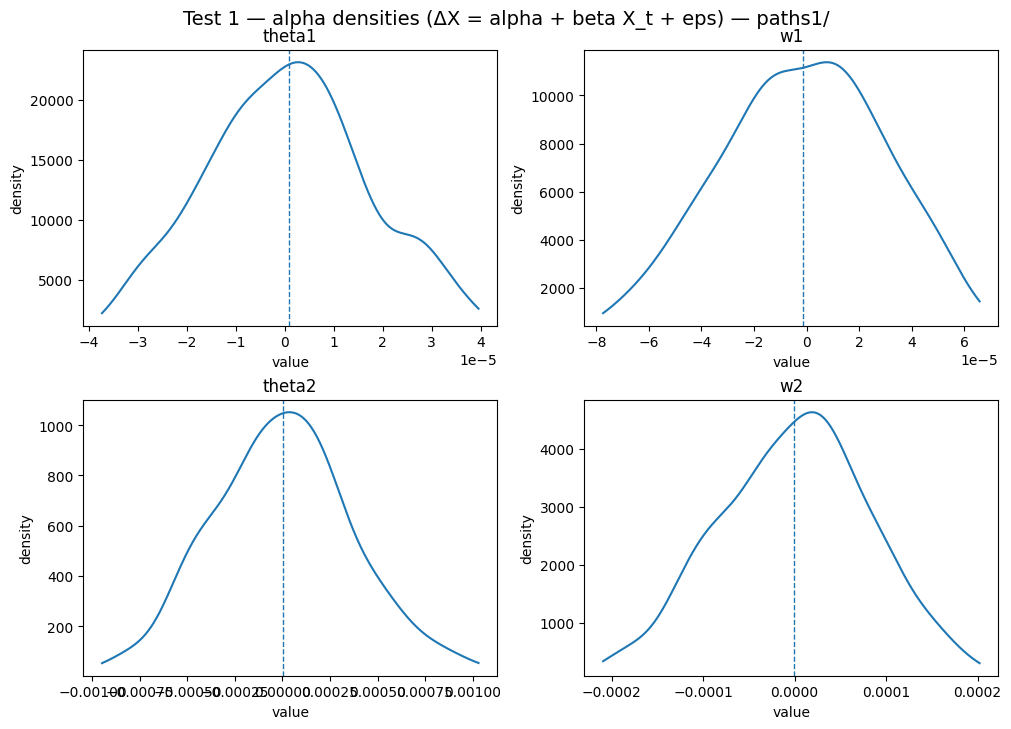

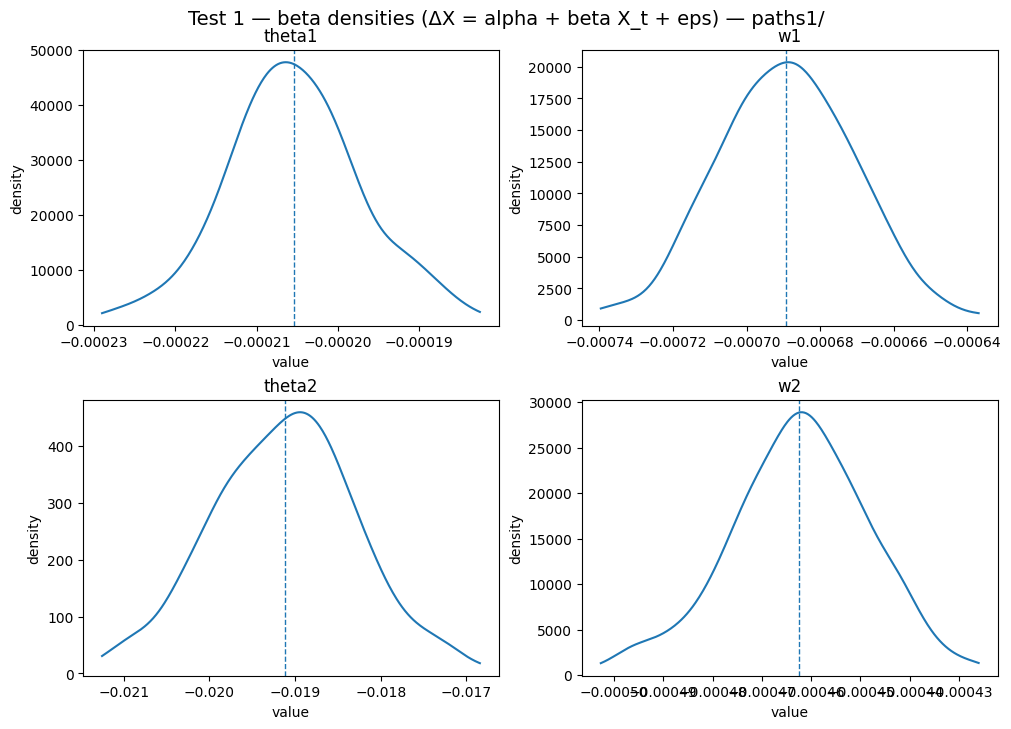

,reject_alpha_0_5pct,reject_beta_0_5pct
observable,,
theta1,0.0,1.0
theta2,0.0,1.0
w1,0.0,1.0
w2,0.0,1.0


In [14]:
plot_coeff_densities_2x2(out1["alphas"], "Test 1 — alpha densities (ΔX = alpha + beta X_t + eps) — paths1/")
plot_coeff_densities_2x2(out1["betas"],  "Test 1 — beta densities (ΔX = alpha + beta X_t + eps) — paths1/")

# Optional: quick aggregate pass/fail counts (e.g., reject alpha=0 or beta=0 at 5%)
# (Martingale support would mean both not significantly different from 0, but interpret cautiously.)
res1 = out1["results_long"].copy()
res1["reject_alpha_0_5pct"] = res1["alpha_p"] < 0.05
res1["reject_beta_0_5pct"]  = res1["beta_p"]  < 0.05
res1.groupby("observable")[["reject_alpha_0_5pct", "reject_beta_0_5pct"]].mean()

In [15]:

out2 = process_folder("paths2", print_every=50)


[  50/1000] -0.3827434448395981-5.304564401944914-1.7581921607943416--2.45445838591855.csv
      obs     alpha      beta       alpha_p        beta_p    nobs
0  theta1 -0.000002 -0.031197  9.986539e-01  0.000000e+00  100001
1      w1  0.005209 -0.001783  6.145475e-10  3.558352e-21  100001
2  theta2  0.000088 -0.044191  9.586079e-01  0.000000e+00  100001
3      w2  0.005127 -0.001367  1.878875e-07  1.107847e-16  100001

[ 100/1000] -0.7680185571022107--4.296131056357952-2.248538500607144--11.277527185243766.csv
      obs     alpha      beta       alpha_p        beta_p    nobs
0  theta1  0.000031 -0.032899  9.827944e-01  0.000000e+00  100001
1      w1 -0.006155 -0.002043  5.581429e-11  5.019631e-24  100001
2  theta2 -0.000756 -0.049285  6.727330e-01  0.000000e+00  100001
3      w2 -0.003333 -0.001071  3.967253e-04  1.945888e-13  100001

[ 150/1000] -1.0692309222638094--8.46672493972712--1.124002604998675-9.779823853881545.csv
      obs     alpha      beta       alpha_p        beta_p    n

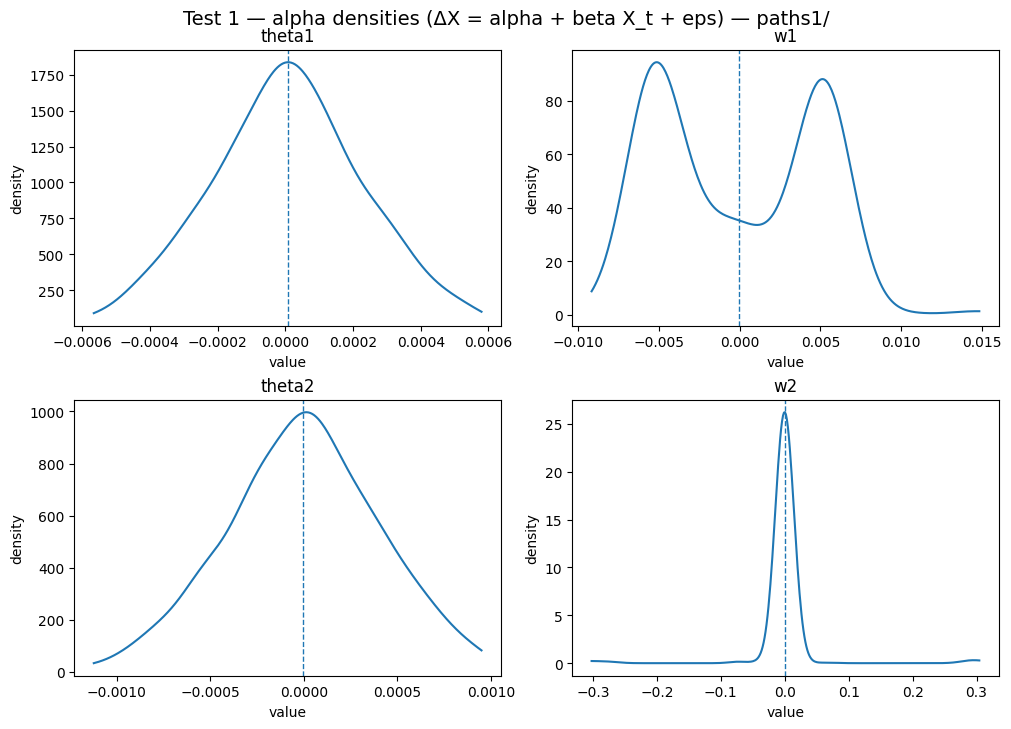

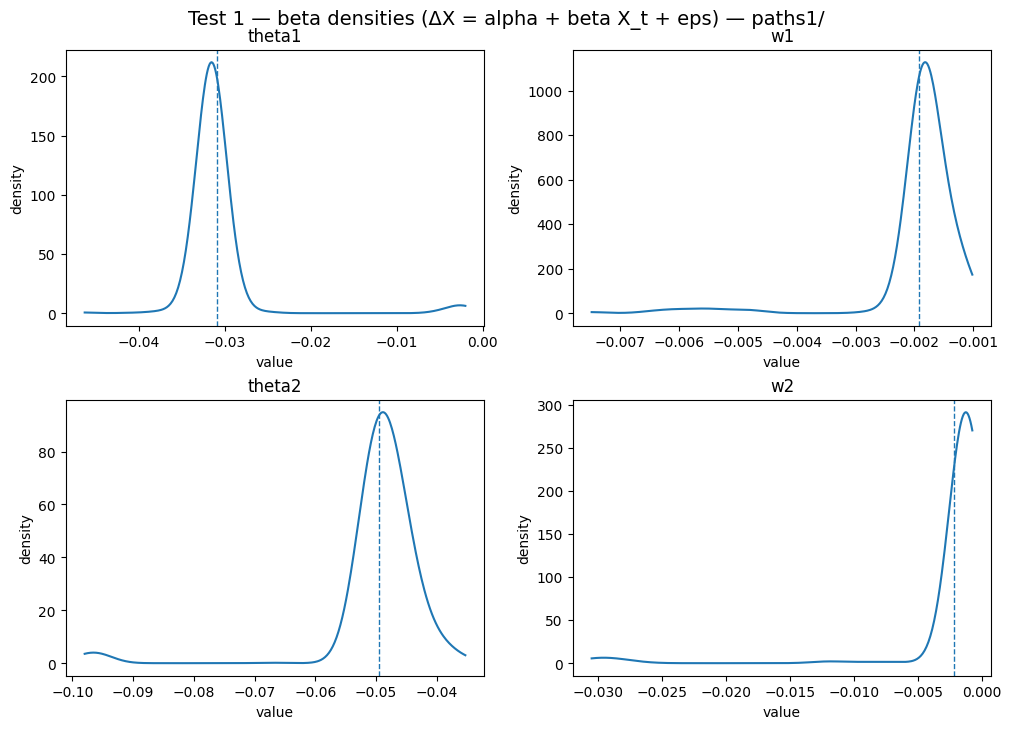

,reject_alpha_0_5pct,reject_beta_0_5pct
observable,,
theta1,0.000,1.0
theta2,0.000,1.0
w1,0.898,1.0
w2,0.907,1.0


In [16]:
plot_coeff_densities_2x2(out2["alphas"], "Test 1 — alpha densities (ΔX = alpha + beta X_t + eps) — paths1/")
plot_coeff_densities_2x2(out2["betas"],  "Test 1 — beta densities (ΔX = alpha + beta X_t + eps) — paths1/")

# Optional: quick aggregate pass/fail counts (e.g., reject alpha=0 or beta=0 at 5%)
# (Martingale support would mean both not significantly different from 0, but interpret cautiously.)
res2 = out2["results_long"].copy()
res2["reject_alpha_0_5pct"] = res2["alpha_p"] < 0.05
res2["reject_beta_0_5pct"]  = res2["beta_p"]  < 0.05
res2.groupby("observable")[["reject_alpha_0_5pct", "reject_beta_0_5pct"]].mean()